In [ ]:
# CELL 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


import os
PROJECT_DIR = '/content/drive/MyDrive/MusicGenerationCSE425'
os.makedirs(PROJECT_DIR, exist_ok=True)
print(f"Project directory: {PROJECT_DIR}")

Mounted at /content/drive
Project directory: /content/drive/MyDrive/MusicGenerationCSE425


In [ ]:
#CELL 1: Setup and Install miditok for tokenization
!pip install pretty_midi miditok -q
from google.colab import drive
drive.mount('/content/drive')
import os, numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

PROJECT_DIR = '/content/drive/MyDrive/MusicGenerationCSE425'
MAESTRO_DIR  = f'{PROJECT_DIR}/data/raw_midi/maestro-v3.0.0'
MODELS_DIR   = f'{PROJECT_DIR}/models_saved'
MIDI_OUT_DIR = f'{PROJECT_DIR}/outputs/generated_midis'
PLOTS_DIR    = f'{PROJECT_DIR}/outputs/plots'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 66.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.0/159.0 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 91.0 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [ ]:
#CELL 2: Tokenize MIDI files using miditok REMI scheme
#Converts MIDI events to integer token sequences
import pandas as pd
from miditok import REMI, TokenizerConfig

#Configure tokenizer
config = TokenizerConfig(
num_velocities=32, use_chords=False, use_programs=False)
tokenizer = REMI(config)

#Load metadata
df = pd.read_csv(f"{MAESTRO_DIR}/maestro-v3.0.0.csv")
train_df = df[df['split'] == 'train']

#Tokenize first 200 training files
print("Tokenizing MIDI files...")
all_token_sequences = []

for fname in train_df['midi_filename'].head(200).tolist():
    fpath = os.path.join(MAESTRO_DIR, fname)
    try:
        tokens = tokenizer(fpath) #returns TokenizerOutput
        #tokens[0] is the first track and .ids gives the integer list
        seq = tokens[0].ids
        if len(seq) >= 128:
            all_token_sequences.append(seq)
    except Exception:
        continue

VOCAB_SIZE = len(tokenizer)
print(f"Tokenized {len(all_token_sequences)} files")
print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Sample sequence length range: "
      f"{min(len(s) for s in all_token_sequences)} – "
      f"{max(len(s) for s in all_token_sequences)}")

Tokenizing MIDI files...
Tokenized 200 files
Vocabulary size: 284
Sample sequence length range: 1525 – 68993


In [ ]:
#CELL 3: Sequence Dataset for Transformer
SEQ_LEN = 256 #number of tokens per training example

class MIDITokenDataset(Dataset):
    #Converts a list of token sequences into fixed-length windows for autoregressive next-token prediction.

    def __init__(self, token_sequences, seq_len=SEQ_LEN):
        self.samples = []
        for seq in token_sequences:
            #Slide a window of seq_len+1 across the sequence
            for start in range(0, len(seq) - seq_len, seq_len // 2):
                chunk = seq[start : start + seq_len + 1]
                if len(chunk) == seq_len + 1:
                    self.samples.append(chunk)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        chunk  = torch.tensor(self.samples[idx], dtype=torch.long)
        inp = chunk[:-1] #Input: first seq_len tokens
        target = chunk[1:] #Target: next seq_len tokens (shifted by 1)
        return inp, target

#Split into 90% train, 10% val
split_idx   = int(0.9 * len(all_token_sequences))
train_seqs  = all_token_sequences[:split_idx]
val_seqs    = all_token_sequences[split_idx:]

train_dataset = MIDITokenDataset(train_seqs)
val_dataset   = MIDITokenDataset(val_seqs)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader    = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

print(f"Dataset ready: {len(train_dataset)} train samples, {len(val_dataset)} val samples")

Dataset ready: 31759 train samples, 3639 val samples


In [ ]:
#CELL 4: Decoder-Only Transformer Architecture
#Implements autoregressive next-token prediction:
#p(X) = product_t p(x_t | x_<t)
import math

class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=1024, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)


        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term) #even dimensions
        pe[:, 1::2] = torch.cos(position * div_term) #odd dimensions
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):

        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class MusicTransformer(nn.Module):
    """Decoder-only Transformer for autoregressive music generation.
    Architecture:
      token_embedding to positional_encoding to N × TransformerDecoderLayer to linear projection to logits over vocabulary
    The causal mask ensures each position can only attend to previous positions (no future peeking!).
    """
    def __init__(self, vocab_size, d_model=256, nhead=8, num_layers=4, dim_feedforward=512, dropout=0.1, max_seq_len=512):
        super().__init__()
        self.d_model = d_model

        #Token embedding
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_seq_len, dropout)

        #Transformer decoder
        decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        #Final projection to vocabulary size
        self.output_projection = nn.Linear(d_model, vocab_size)
        self._init_weights()

    def _init_weights(self):

        nn.init.normal_(self.token_embedding.weight, std=0.02)
        nn.init.normal_(self.output_projection.weight, std=0.02)

    def generate_causal_mask(self, seq_len, device):
        mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1).bool()
        return mask

    def forward(self, x):

        seq_len = x.size(1)


        causal_mask = self.generate_causal_mask(seq_len, x.device)

        #Embed tokens + add positional encoding
        emb = self.token_embedding(x) * math.sqrt(self.d_model)
        emb = self.pos_encoding(emb)

        #Run through transformer
        out = self.transformer(emb, emb, tgt_mask=causal_mask, memory_mask=causal_mask)

        logits = self.output_projection(out)
        return logits


#Instantiate model
transformer = MusicTransformer(vocab_size=VOCAB_SIZE, d_model=256, nhead=8, num_layers=4, dim_feedforward=512, dropout=0.1).to(DEVICE)
total_params = sum(p.numel() for p in transformer.parameters() if p.requires_grad)
print(f"MusicTransformer ready — Trainable parameters: {total_params:,}")

MusicTransformer ready — Trainable parameters: 3,308,828


In [ ]:
#CELL 5: Transformer Training Loop with Perplexity Metric
EPOCHS = 50
LR = 3e-4
CLIP_NORM = 1.0

optimizer = torch.optim.Adam(transformer.parameters(), lr=LR, betas=(0.9, 0.98))
criterion = nn.CrossEntropyLoss(ignore_index=0)  #0 = padding token

train_losses = []
val_perplexities = []
best_val_perplexity = float('inf')

print(f"Training MusicTransformer for {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS + 1):
    #Training
    transformer.train()
    total_loss = 0.0

    for inp, target in train_loader:
        inp, target = inp.to(DEVICE), target.to(DEVICE)
        optimizer.zero_grad()

        logits = transformer(inp)

        loss = criterion(logits.reshape(-1, VOCAB_SIZE), target.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(transformer.parameters(), CLIP_NORM)
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    #Validation + Perplexity
    transformer.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for inp, target in val_loader:
            inp, target = inp.to(DEVICE), target.to(DEVICE)
            logits = transformer(inp)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), target.reshape(-1))
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_perplexity = torch.exp(torch.tensor(avg_val_loss)).item()

    train_losses.append(avg_train_loss)
    val_perplexities.append(val_perplexity)

    if val_perplexity < best_val_perplexity:
        best_val_perplexity = val_perplexity
        torch.save(transformer.state_dict(), f"{MODELS_DIR}/task3_transformer_best.pth")

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Perplexity: {val_perplexity:.2f}")

print(f"\nBest Val Perplexity: {best_val_perplexity:.2f}")

Training MusicTransformer for 50 epochs...

Epoch   1/50 | Train Loss: 2.6914 | Val Perplexity: 9.93
Epoch   5/50 | Train Loss: 2.0959 | Val Perplexity: 7.71
Epoch  10/50 | Train Loss: 1.9544 | Val Perplexity: 7.14
Epoch  15/50 | Train Loss: 1.8825 | Val Perplexity: 6.97
Epoch  20/50 | Train Loss: 1.8361 | Val Perplexity: 6.91
Epoch  25/50 | Train Loss: 1.8039 | Val Perplexity: 6.80
Epoch  30/50 | Train Loss: 1.7799 | Val Perplexity: 6.76
Epoch  35/50 | Train Loss: 1.7614 | Val Perplexity: 6.79
Epoch  40/50 | Train Loss: 1.7458 | Val Perplexity: 6.78
Epoch  45/50 | Train Loss: 1.7332 | Val Perplexity: 6.85
Epoch  50/50 | Train Loss: 1.7225 | Val Perplexity: 6.78

Best Val Perplexity: 6.72


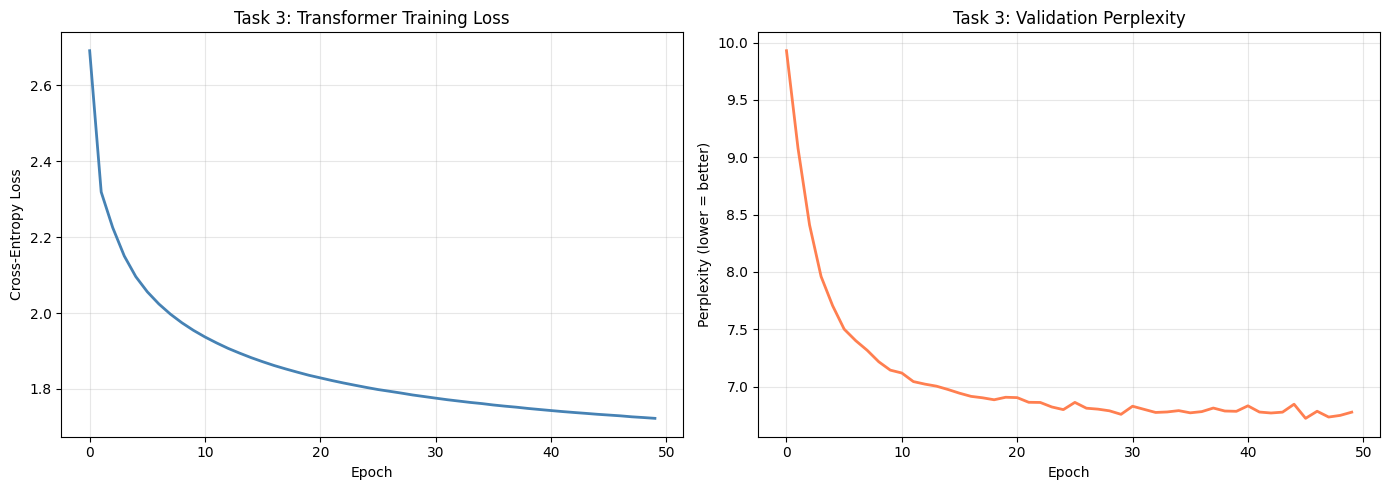

Perplexity plot saved! Final perplexity: 6.78


In [ ]:
#CELL 6: Plot Perplexity Curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, color='steelblue', linewidth=2)
ax1.set_title('Task 3: Transformer Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.grid(alpha=0.3)

ax2.plot(val_perplexities, color='coral', linewidth=2)
ax2.set_title('Task 3: Validation Perplexity')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Perplexity (lower = better)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/task3_transformer_perplexity.png", dpi=150)
plt.show()
print(f"Perplexity plot saved! Final perplexity: {val_perplexities[-1]:.2f}")

In [ ]:
#CELL 7: Generate 10 Long-Sequence Compositions
#Uses temperature sampling to avoid repetition loops
#miditok v3.x API: tokenizer.decode() accepts list of ints

transformer.load_state_dict(torch.load(f"{MODELS_DIR}/task3_transformer_best.pth",map_location=DEVICE))
transformer.eval()

def generate_sequence(model, device, max_new_tokens=512, temperature=1.0, top_k=50):
    """
    Autoregressively generate a token sequence using top-k sampling.
    Args:
        model : trained MusicTransformer
        device : CPU or CUDA
        max_new_tokens : number of tokens to generate
        temperature : >1 = more random, <1 = more deterministic
        top_k : keep only the top-k most likely tokens at each step
    Returns:
        List of integer token IDs
    """
    start_token = 1  # Bar_None token in REMI vocabulary
    generated = [start_token]

    with torch.no_grad():
        for _ in range(max_new_tokens):
            inp = torch.tensor([generated], dtype=torch.long).to(device)
            logits = model(inp) #(1, seq_len, vocab_size)
            next_logits = logits[0, -1] # logits for the very next token

            #Temperature scaling
            next_logits = next_logits / temperature

            #Top-k filtering: mask all tokens below the k-th highest logit
            if top_k > 0:
                topk_vals, _ = torch.topk(next_logits, top_k)
                threshold = topk_vals[-1]
                next_logits[next_logits < threshold] = -float('inf')

            #Sample next token
            probs = torch.softmax(next_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).item()
            generated.append(next_token)

            if len(generated) >= max_new_tokens:
                break

    return generated


#Main generation loop
print("Generating 10 long-sequence compositions for Task 3\n")

for i in range(10):
    temp = 0.9 + i * 0.02  #slight variation for diversity
    tokens = generate_sequence(transformer, DEVICE, max_new_tokens=512, temperature=temp, top_k=40)

    #Filter out-of-range token IDs before decoding
    vocab_size = len(tokenizer)
    tokens_clean = [t for t in tokens if 0 <= t < vocab_size]

    out_path = f"{MIDI_OUT_DIR}/task3_transformer_{i+1}.mid"
    try:
        score = tokenizer.decode([tokens_clean]) #miditok v3.x: expects list of sequences
        score.dump_midi(out_path)
        print(f"Composition {i+1}: {len(tokens)} tokens -> {out_path}")
    except Exception as e:
        print(f"Composition {i+1}: FAILED - {e}")

print("\nTask 3 generation complete!")

Generating 10 long-sequence compositions for Task 3

Composition 1: 512 tokens -> /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task3_transformer_1.mid
Composition 2: 512 tokens -> /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task3_transformer_2.mid
Composition 3: 512 tokens -> /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task3_transformer_3.mid
Composition 4: 512 tokens -> /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task3_transformer_4.mid
Composition 5: 512 tokens -> /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task3_transformer_5.mid
Composition 6: 512 tokens -> /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task3_transformer_6.mid
Composition 7: 512 tokens -> /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/task3_transformer_7.mid
Composition 8: 512 tokens -> /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_m

In [ ]:
#CELL 8: Generate 20 Survey Samples for Task 4 RLHF
print("Generating 20 survey samples for RLHF human rating\n")

for i in range(20):
    temp = 0.85 + i * 0.02  #vary temperature for diversity
    tokens = generate_sequence(transformer, DEVICE, max_new_tokens=512, temperature=temp, top_k=40)
    vocab_size = len(tokenizer)
    tokens_clean = [t for t in tokens if 0 <= t < vocab_size]

    out_path = f"{MIDI_OUT_DIR}/rlhf_survey_sample_{i+1}.mid"
    try:
        score = tokenizer.decode([tokens_clean])
        score.dump_midi(out_path)
        print(f"Sample {i+1}: {len(tokens)} tokens -> {out_path}")
    except Exception as e:
        print(f"Sample {i+1}: FAILED - {e}")

print("\n20 survey samples saved!")

Generating 20 survey samples for RLHF human rating

Sample 1: 512 tokens -> /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/rlhf_survey_sample_1.mid
Sample 2: 512 tokens -> /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/rlhf_survey_sample_2.mid
Sample 3: 512 tokens -> /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/rlhf_survey_sample_3.mid
Sample 4: 512 tokens -> /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/rlhf_survey_sample_4.mid
Sample 5: 512 tokens -> /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/rlhf_survey_sample_5.mid
Sample 6: 512 tokens -> /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/rlhf_survey_sample_6.mid
Sample 7: 512 tokens -> /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/rlhf_survey_sample_7.mid
Sample 8: 512 tokens -> /content/drive/MyDrive/MusicGenerationCSE425/outputs/generated_midis/rlhf_survey_sample_8.mid
Samp